### Icefield Domain Sites Figures (copied from 2_merge_netcdfs.ipynb)

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [2]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray  # For CRS handling

In [3]:
pwd

'/home/cassie/python/repos/snow_modeling_point/icefield_domain'

## Load HRRR-AK UTM NetCDFs 

In [4]:
# Path to the UTM NetCDF file
output_merged_path = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm.nc'

# Load the dataset
ds_utm = xr.open_dataset(output_merged_path)

In [5]:
# lat_ppsa, lon_ppsa = 58.26200, -134.51700
# lat_tram, lon_tram = 58.2971, -134.386
# lat_heen, lon_heen = 58.69652, -134.86448
# lat_tkg4, lon_tkg4 = 58.63447,-134.23708
# lat_mld4, lon_mld4 = 58.85892,-134.15728

# Plot the Sites

### First, as a map

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Text(0.5, 1.0, 'HRRR temp (single timestep) with site locations')

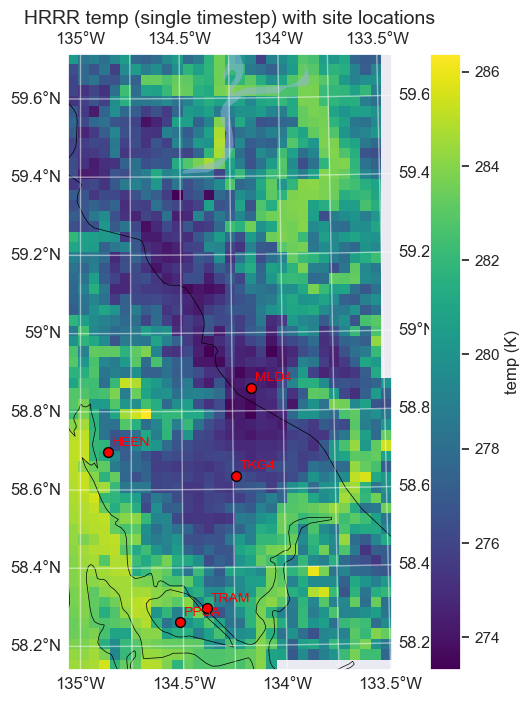

In [7]:
# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.23708},
    "mld4": {"lat": 58.85892, "lon": -134.15728}
}

# Create GeoDataFrame for sites
gdf_sites = gpd.GeoDataFrame({
    "site": list(sites.keys()),
    "geometry": [Point(sites[site]["lon"], sites[site]["lat"]) for site in sites]
}, crs="EPSG:4326")

# Convert sites to UTM (same as dataset)
gdf_sites_utm = gdf_sites.to_crs("EPSG:32608")

# Select a variable for background (e.g., temp at first time step)
var_name = 'temp'  # Change to any variable, e.g., 'temp', 'precip_total'
background_data = ds_utm[var_name].isel(time=0)  # First time step

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(8)})  # UTM Zone 8N

# Plot the background raster
background_data.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'label': f'{var_name} ({background_data.attrs.get("units", "")})'})

# Add coastlines and features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, alpha=0.5)

# Plot site points
for idx, row in gdf_sites_utm.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    ax.text(x + 1000, y + 1000, row['site'].upper(), fontsize=10, color='red', ha='left', va='bottom', zorder=6)

# Set title
ax.set_title(f"HRRR {var_name} (single timestep) with site locations", fontsize=14)

# # Save or show the plot
# plt.tight_layout()
# plt.savefig("/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_temp_sites_map.png", dpi=300)
# plt.show()

# print("✅ Map plotted and saved!")

Text(0.5, 1.0, 'HRRR orog (single timestep) with site locations')

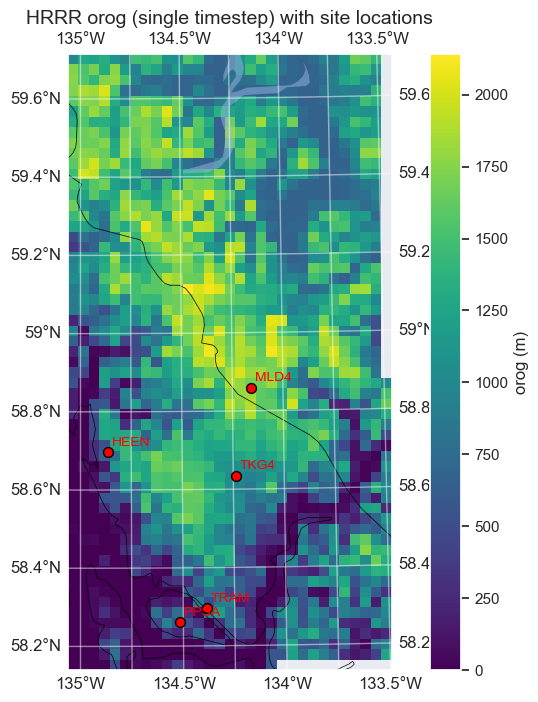

In [51]:
# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.23708},
    "mld4": {"lat": 58.85892, "lon": -134.15728}
}

# Create GeoDataFrame for sites
gdf_sites = gpd.GeoDataFrame({
    "site": list(sites.keys()),
    "geometry": [Point(sites[site]["lon"], sites[site]["lat"]) for site in sites]
}, crs="EPSG:4326")

# Convert sites to UTM (same as dataset)
gdf_sites_utm = gdf_sites.to_crs("EPSG:32608")

# Select a variable for background (e.g., temp at first time step)
var_name = 'orog'  # Change to any variable, e.g., 'temp', 'precip_total'
background_data = ds_utm[var_name].isel(time=0)  # First time step

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(8)})  # UTM Zone 8N

# Plot the background raster
background_data.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'label': f'{var_name} ({background_data.attrs.get("units", "")})'})

# Add coastlines and features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, alpha=0.5)

# Plot site points
for idx, row in gdf_sites_utm.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    ax.text(x + 1000, y + 1000, row['site'].upper(), fontsize=10, color='red', ha='left', va='bottom', zorder=6)

# Set title
ax.set_title(f"HRRR {var_name} (single timestep) with site locations", fontsize=14)

# # Save or show the plot
# plt.tight_layout()
# plt.savefig("/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_temp_sites_map.png", dpi=300)
# plt.show()

# print("✅ Map plotted and saved!")

Calculating a few numbers to manually zoom into the figure below,

In [16]:
ds_utm['y'].max().values - ds_utm['y'].min().values

np.float64(172433.62918437272)

In [18]:
( ds_utm['y'].max().values - ds_utm['y'].min().values ) / 3

np.float64(57477.87639479091)

In [20]:
( ds_utm['x'].max().values - ds_utm['x'].min().values ) / 10

np.float64(8918.980819881359)

## like the other sites figure in the Juneau Domain code, 

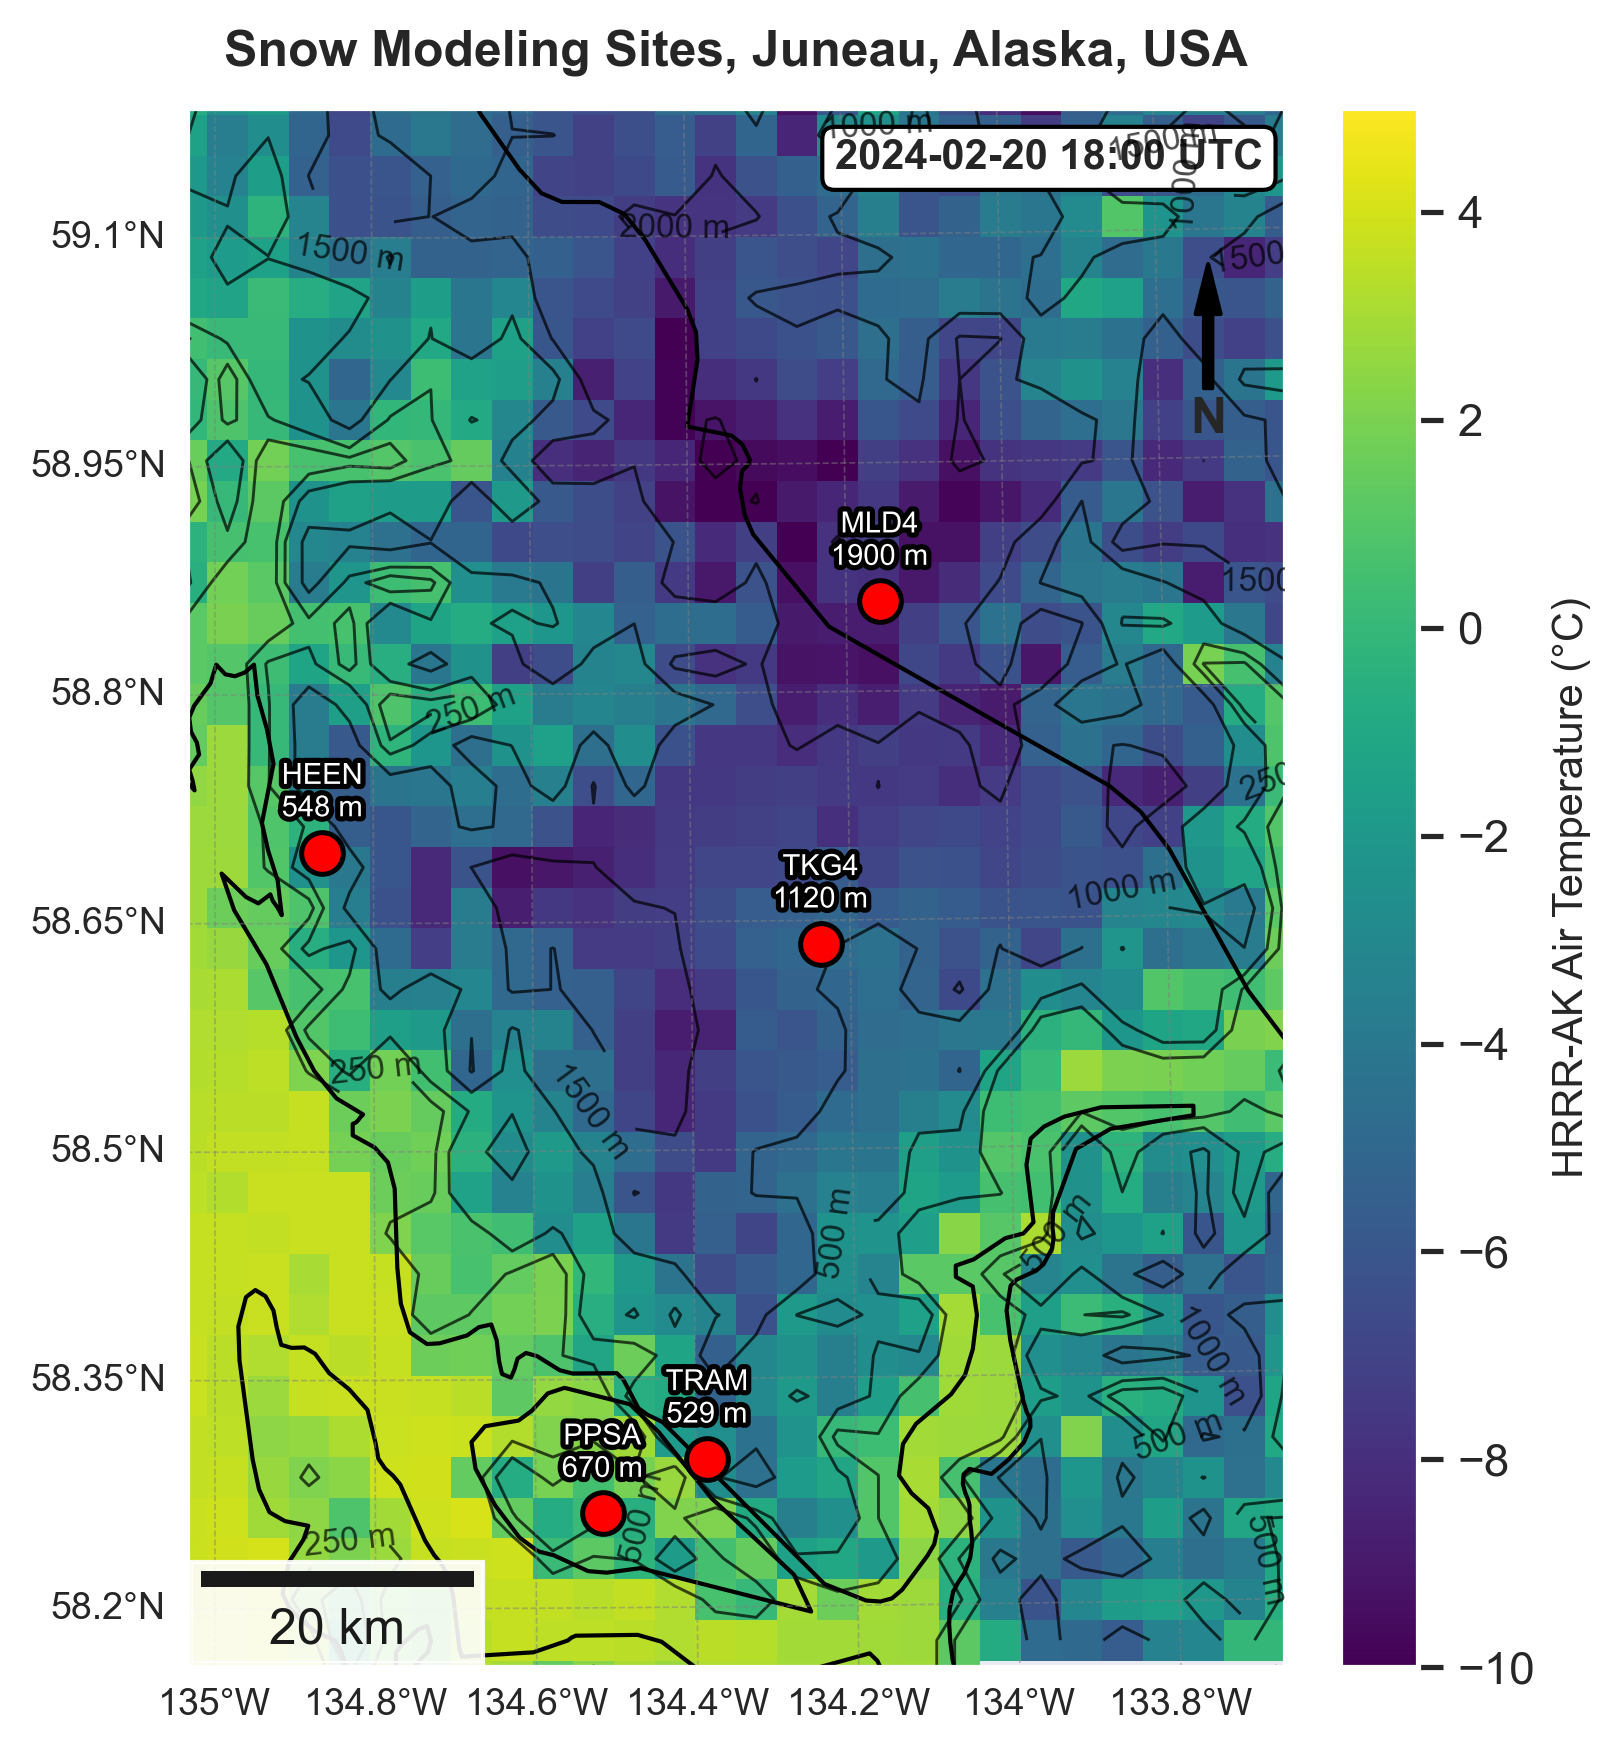

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point
import pandas as pd
import numpy as np

# =============================================================================
# USER SETTINGS
# =============================================================================

# Select datetime to plot
# plot_time = "2021-02-01T00:00:00"

# Temperature colorbar limits
temp_min = -10
temp_max = 5

# =============================================================================
# SITE INFORMATION
# =============================================================================

sites = {
    "PPSA": {
        "lat": 58.26200,
        "lon": -134.51700,
        "elev": 670,
    },
    "TRAM": {
        "lat": 58.2971,
        "lon": -134.386,
        "elev": 529,
    },
    "HEEN": {
        "lat": 58.69652,
        "lon": -134.86448,
        "elev": 548,
    },
    
    "TKG4": {
        "lat": 58.63447,
        "lon": -134.23708,
        "elev": 1120,  
    },
    "MLD4": {
        "lat": 58.85892,
        "lon": -134.15728,
        "elev": 1900,  
    }
}

# =============================================================================
# CREATE GEODATAFRAME
# =============================================================================

gdf_sites = gpd.GeoDataFrame(
    {
        "site_id": list(sites.keys()),
        "elev_m": [sites[s]["elev"] for s in sites],
        "geometry": [
            Point(sites[s]["lon"], sites[s]["lat"])
            for s in sites
        ]
    },
    crs="EPSG:4326"
)

# =============================================================================
# MAP DOMAIN
# =============================================================================

# lon_min = -135.15
# lon_max = -134.20
# lat_min = 58.10
# lat_max = 58.80

proj = ccrs.UTM(8)

# Limit maximum latitude to 59N
lat_max = 59
lat_max_utm = proj.transform_point(0, lat_max, ccrs.PlateCarree())[1]


# =============================================================================
# FIGURE SETUP
# =============================================================================

fig = plt.figure(figsize=(7, 6), dpi=300)

ax = plt.axes(projection=proj)


# =============================================================================
# SELECT TEMPERATURE DATA
# =============================================================================

plot_time = pd.to_datetime("2024-02-20T18:00:00")

temp = (
    ds_utm['temp']
    .sel(time=plot_time, method="nearest")
    - 273.15
)

# =============================================================================
# TEMPERATURE MAP
# =============================================================================

im = ax.pcolormesh(
    ds_utm['x'],
    ds_utm['y'],
    temp,
    cmap='viridis',
    shading='auto',
    vmin=temp_min,
    vmax=temp_max,
    transform=proj
)

# =============================================================================
# TOPOGRAPHY CONTOURS
# =============================================================================

terrain = ds_utm['orog'].isel(time=0)

contours = ax.contour(
    terrain['x'],
    terrain['y'],
    terrain.values,
    levels=[250, 500, 1000, 1500, 2000],
    colors='black',
    linewidths=0.7,
    alpha=0.7,
    transform=proj
)

ax.clabel(
    contours,
    inline=True,
    fontsize=8,
    fmt='%d m'
)

# =============================================================================
# MAP FEATURES
# =============================================================================

# Limit y_max to lat_max_utm
y_max = ds_utm['y'].max().values - 57477
x_max = ds_utm['x'].max().values - 8918

ax.set_extent(
    [ds_utm['x'].min().values,
     x_max,
     ds_utm['y'].min().values + 1000,
     y_max],
    crs=proj
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=1
)

# add country boarders
ax.add_feature(
    cfeature.BORDERS,
    linewidth=1
)

ax.add_feature(
    cfeature.LAKES,
    alpha=0.5
)

# =============================================================================
# GRIDLINES
# =============================================================================

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# =============================================================================
# SITE MARKERS
# =============================================================================

for idx, row in gdf_sites.iterrows():

    lon = row.geometry.x
    lat = row.geometry.y

    ax.scatter(
        lon,
        lat,
        s=100,
        c='red',
        edgecolor='black',
        linewidth=1.2,
        zorder=7,
        transform=ccrs.PlateCarree()
    )

    txt = ax.text(
        lon,
        lat + 0.02,
        f"{row['site_id']}\n{int(row['elev_m'])} m",
        fontsize=7,
        # fontweight='bold',
        ha='center',
        va='bottom',
        color='white',
        transform=ccrs.PlateCarree(),
        zorder=11
    )

    txt.set_path_effects([
        pe.withStroke(
            linewidth=2.5,
            foreground='black'
        )
    ])

# =============================================================================
# SCALE BAR
# =============================================================================

scalebar = ScaleBar(
    1,
    units='m',
    location='lower left',
    length_fraction=0.25,
    box_alpha=0.9
)

ax.add_artist(scalebar)

# =============================================================================
# NORTH ARROW
# =============================================================================

ax.annotate(
    'N',
    xy=(0.93, 0.90),
    xytext=(0.93, 0.80),
    arrowprops=dict(
        facecolor='black',
        edgecolor='black',
        width=2,
        headwidth=6
        
    ),
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    xycoords=ax.transAxes
)

# =============================================================================
# TIMESTAMP LABEL
# =============================================================================

timestamp_str = pd.to_datetime(plot_time).strftime('%Y-%m-%d %H:%M UTC')

ax.text(
    0.98,
    0.98,
    timestamp_str,
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        alpha=1,
        boxstyle='round'
    )
)

# =============================================================================
# LANDMARKS
# =============================================================================

# # Reference landmarks
# landmarks = [
#     # ("Downtown Juneau", -134.419, 58.298),
#     ("JNU Airport", -134.576, 58.354),
#     # ("Mendenhall Glacier", -134.552, 58.437)
# ]

# for name, lon, lat in landmarks:
#     ax.scatter(lon, lat, transform=ccrs.PlateCarree(),
#                s=50, c='black', marker='s', edgecolor='white', 
#                linewidth=.5, zorder=8, alpha=0.9)
#     ax.annotate(name, (lon-0.05, lat+0.018), fontsize=7, #fontweight='bold',
#                 color='white', ha='left',
#                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.9),
#                 transform=ccrs.PlateCarree(), zorder=9)

# =============================================================================
# COLORBAR
# =============================================================================

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation='vertical',
    fraction=0.045,
    pad=0.03
)

cbar.set_label(
    'HRRR-AK Air Temperature (°C)',
    fontsize=10, 
    # decrease the size of the tickmarks 
    # tick_params={'labelsize': 7},
    # rotate = 180,
)

# =============================================================================
# TITLE
# =============================================================================

ax.set_title(
    'Snow Modeling Sites, Juneau, Alaska, USA',
    fontsize=12,
    fontweight='bold',
    pad=10
)

# =============================================================================
# LAYOUT
# =============================================================================

plt.tight_layout()

# =============================================================================
# SAVE
# =============================================================================

# plt.savefig(
#     'hrrr_temperature_map.png',
#     dpi=300,
#     bbox_inches='tight'
# )

# plt.savefig(
#     'hrrr_temperature_map.pdf',
#     bbox_inches='tight'
# )

plt.show()

# Timeseries Plots

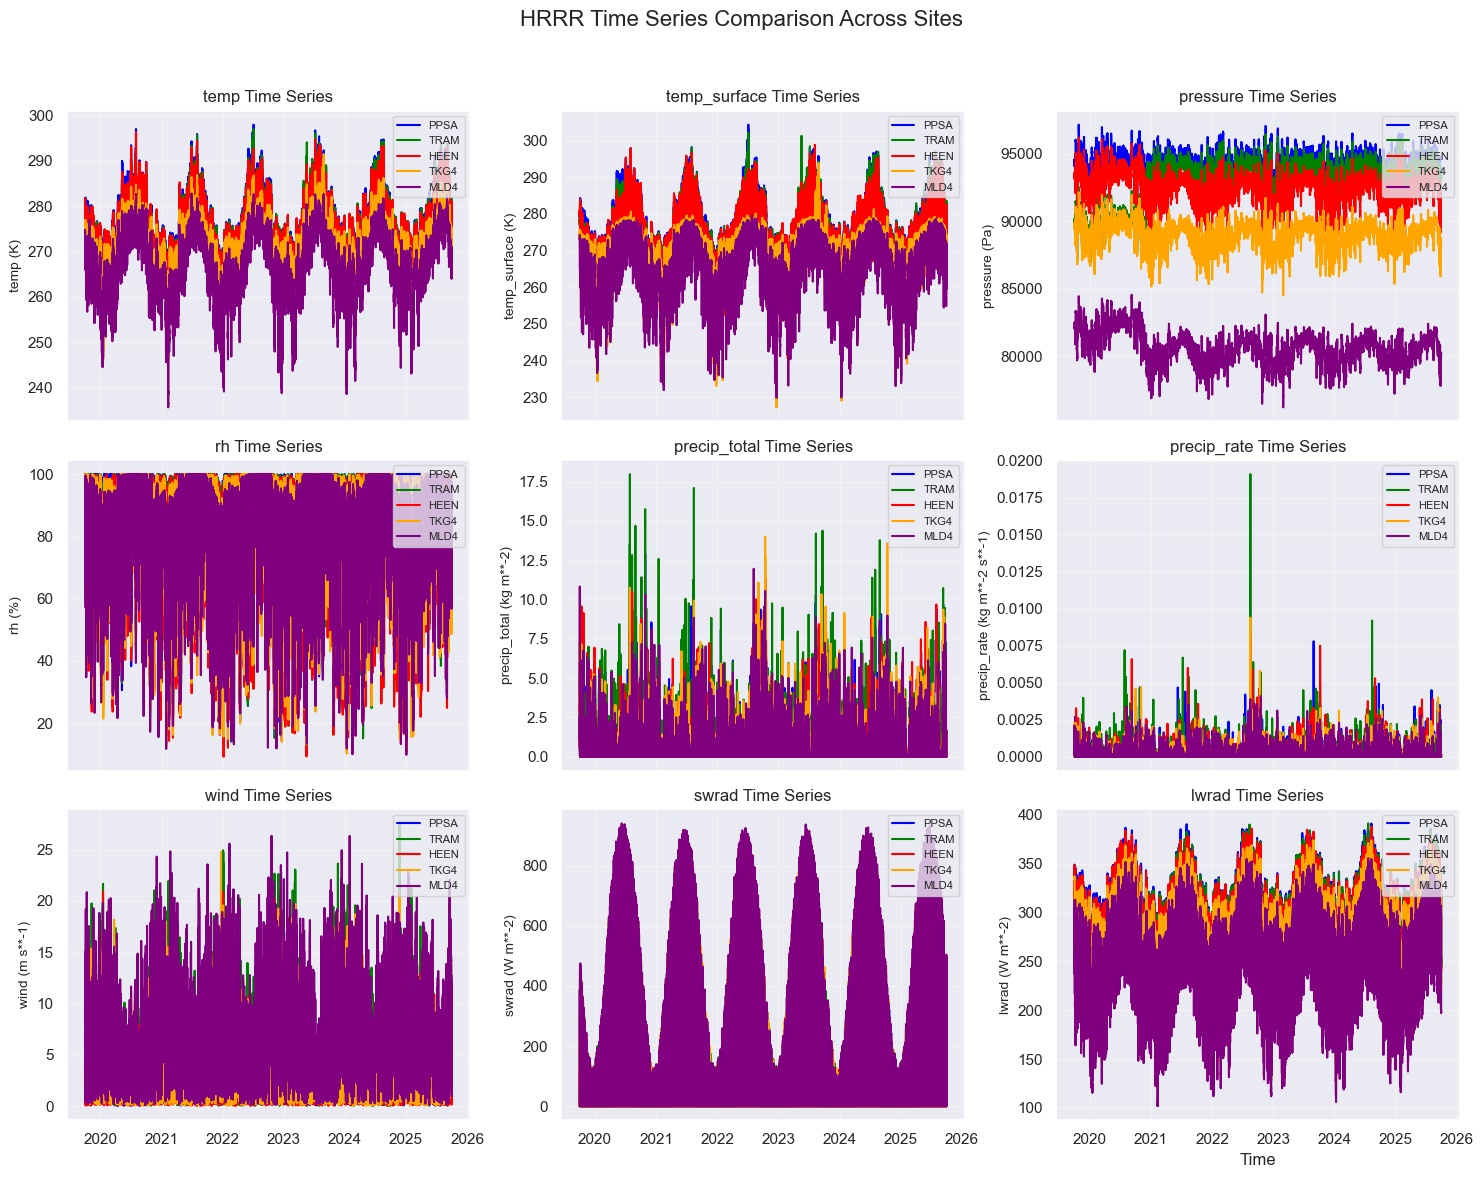

In [15]:
# Paths to site NetCDFs (assuming they were saved as per previous code)
site_files = {
    "ppsa": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc",
    "tram": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc",
    "heen": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc",
    "tkg4": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc",
    "mld4": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc"
}

# Load datasets
site_ds = {}
for site, path in site_files.items():
    ds = xr.open_dataset(path)
    site_ds[site] = ds

# Variables to plot (important for modeling)
variables = ['temp', 'temp_surface', 'pressure', 'rh', 'precip_total', 'precip_rate', 'wind', 'swrad', 'lwrad']

# Colors for sites
colors = {'ppsa': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange', 'mld4': 'purple'}

# Create subplots (3x3 grid for 9 variables)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
axes = axes.flatten()  # Flatten for easy indexing

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            # Convert to pandas for easier plotting (if needed)
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=12)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Set common x-label
axes[-1].set_xlabel("Time", fontsize=12)  # Bottom-right subplot

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# # Save the plot
# output_plot = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_sites_timeseries_comparison.png"
# plt.savefig(output_plot, dpi=300)

plt.show()

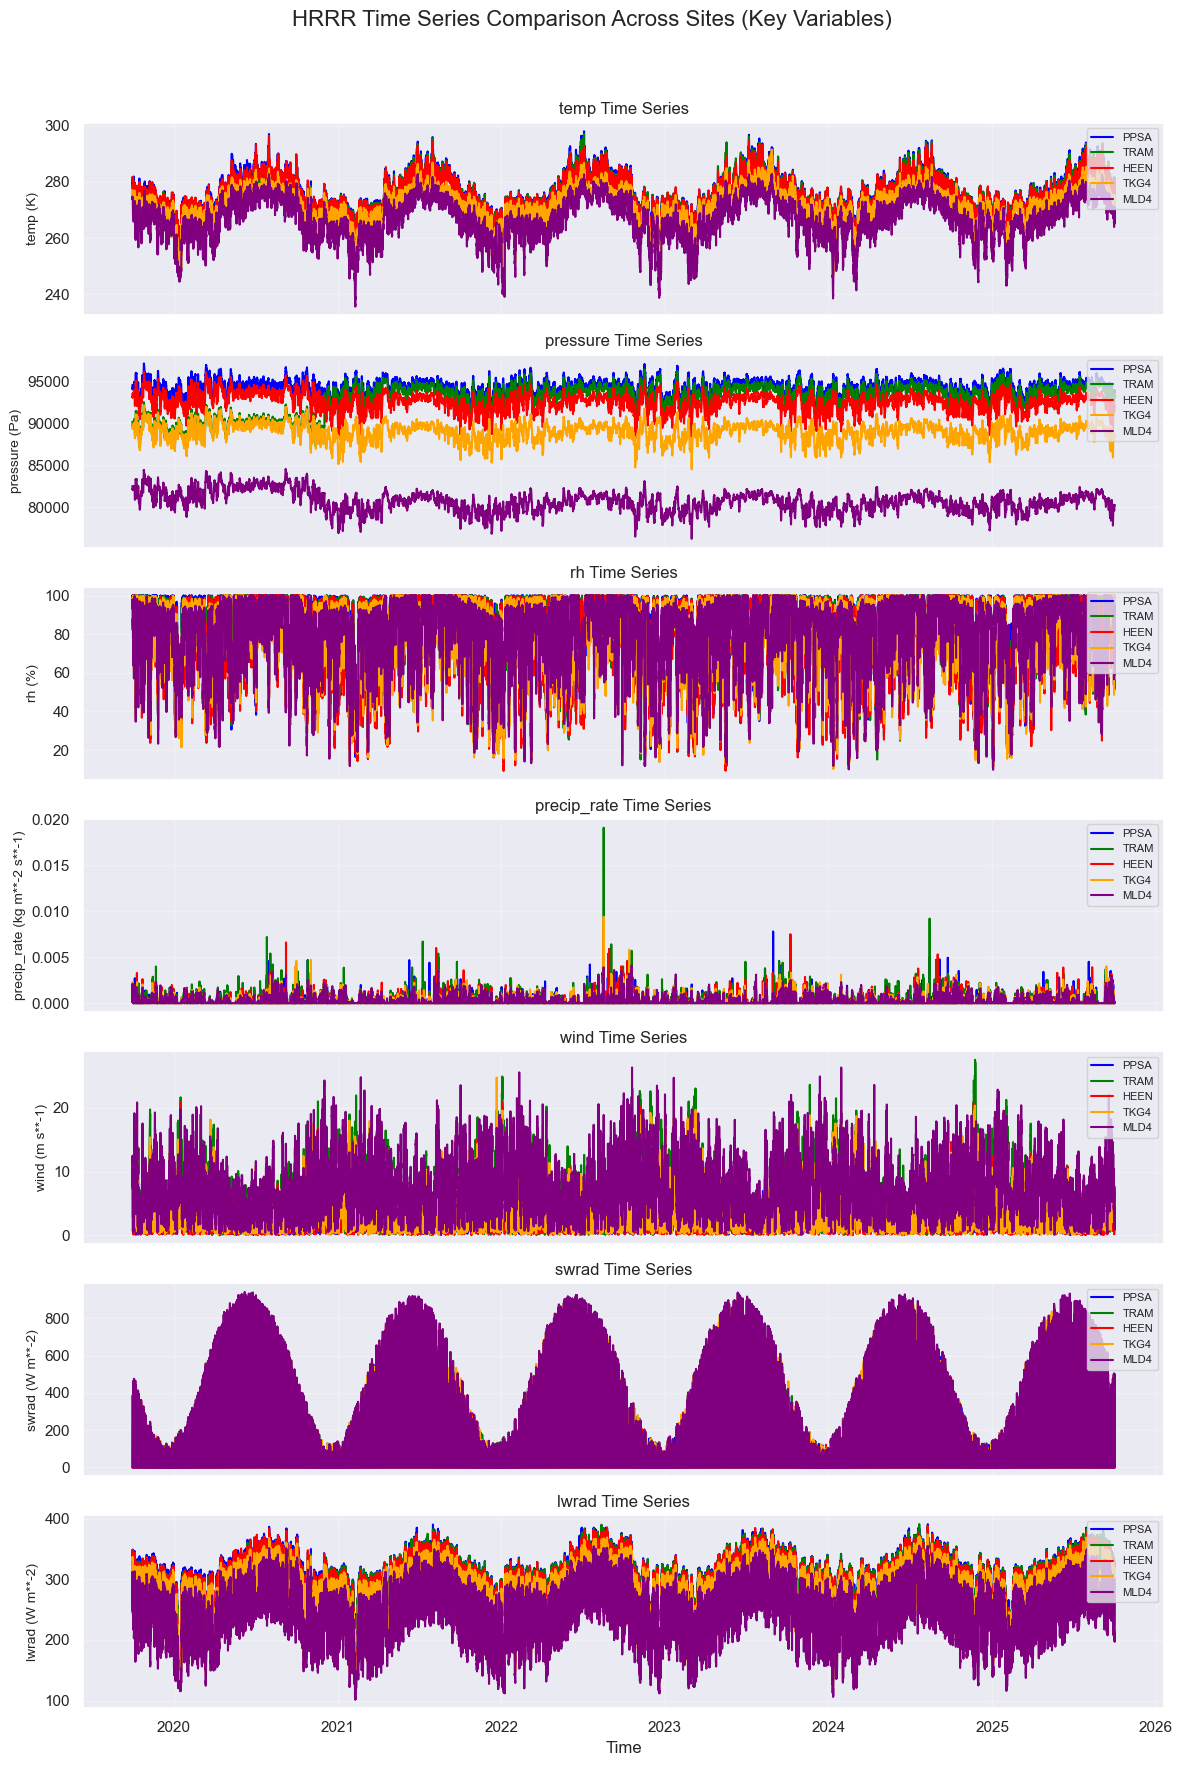

In [16]:
# Variables to plot (subset for modeling)
variables = ['temp', 'pressure', 'rh', 'precip_rate', 'wind', 'swrad', 'lwrad']

# Colors for sites
colors = {'ppsa': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange', 'mld4': 'purple'}

# Create subplots (7 rows, 1 column for wider plots)
fig, axes = plt.subplots(7, 1, figsize=(12, 18), sharex=True)  # Wider and taller

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=12)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Set common x-label on the last subplot
axes[-1].set_xlabel("Time", fontsize=12)

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites (Key Variables)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

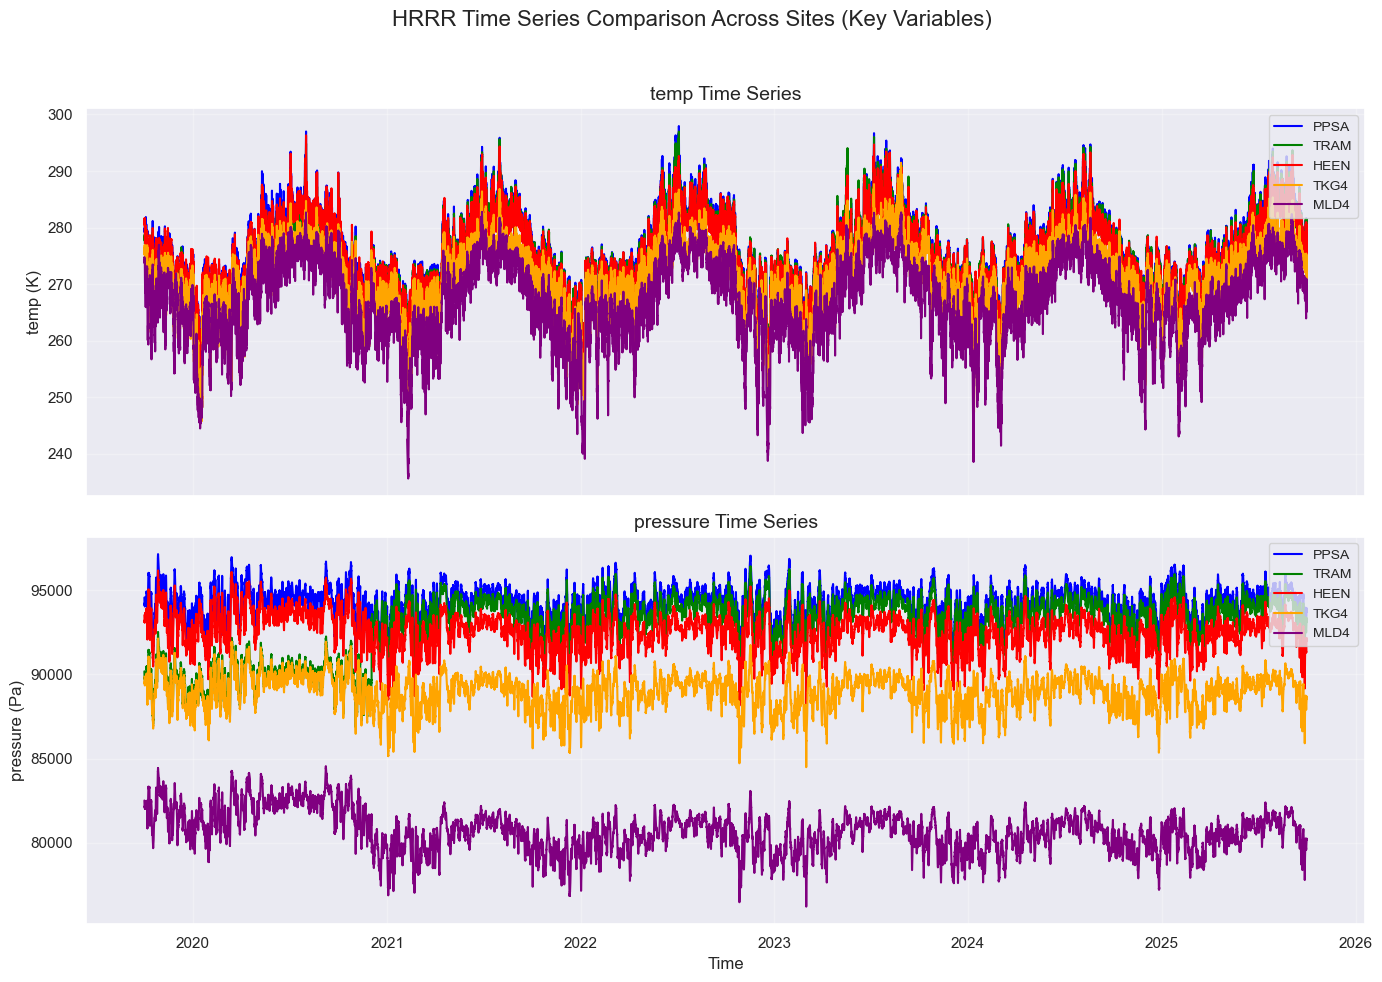

In [53]:
# Variables to plot (subset for modeling)
variables = ['temp', 'pressure']

# Colors for sites
colors = {'ppsa': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange', 'mld4': 'purple'}

# Create subplots (2 rows, 1 column for wider plots)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)  # Wider and taller

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=14)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

# Set common x-label on the last subplot
axes[-1].set_xlabel("Time", fontsize=12)

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites (Key Variables)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finally, print the elevation of of each gridcell to compare 

In [23]:
# compare the gridcell elevation for each site to the field elevation

# ppsa to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc
# tram to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc
# heen to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc
# tkg4 to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc
# mld4 to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc

ppsa_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc")
tram_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc")
heen_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc")
tkg4_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc")
mld4_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc")

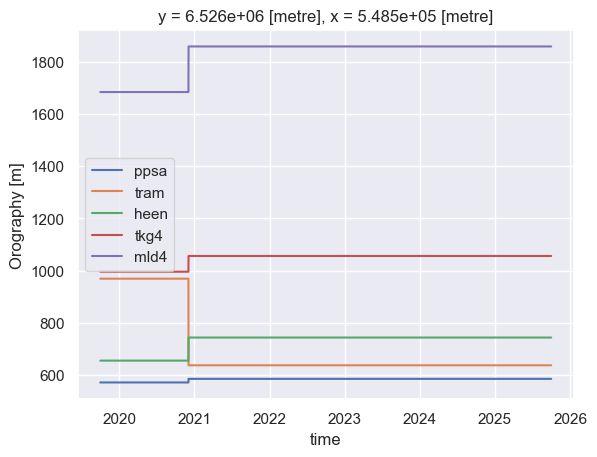

In [37]:
ppsa_ds['orog'].plot()
tram_ds['orog'].plot()
heen_ds['orog'].plot()
tkg4_ds['orog'].plot()
mld4_ds['orog'].plot()

plt.legend(['ppsa', 'tram', 'heen', 'tkg4', 'mld4'])

In [40]:
# print the last elevation of each netcdf
ppsa_ds['orog'][-1].values

# save the last orog value for each site into a df with columns site and elevation_m
df_elevation = pd.DataFrame({
    'site': ['ppsa', 'tram', 'heen', 'tkg4', 'mld4'],
    'hrrrak_elevation_m': [ppsa_ds['orog'][-1].values, tram_ds['orog'][-1].values, heen_ds['orog'][-1].values, tkg4_ds['orog'][-1].values, mld4_ds['orog'][-1].values],
    'real_elevation_m': [669.9, 529.1, 548.0, 1120, 1900]
})
df_elevation

,site,hrrrak_elevation_m,real_elevation_m
0,ppsa,585.550986841321,669.9
1,tram,637.394736841321,529.1
2,heen,743.613486841321,548.0
3,tkg4,1055.800986841321,1120.0
4,mld4,1857.707236841321,1900.0


In [41]:
df_elevation['diff'] = df_elevation['hrrrak_elevation_m'] - df_elevation['real_elevation_m']
df_elevation

,site,hrrrak_elevation_m,real_elevation_m,diff
0,ppsa,585.550986841321,669.9,-84.349013
1,tram,637.394736841321,529.1,108.294737
2,heen,743.613486841321,548.0,195.613487
3,tkg4,1055.800986841321,1120.0,-64.199013
4,mld4,1857.707236841321,1900.0,-42.292763


/tmp/ipykernel_2994083/4107987374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='site', y='diff', data=df_elevation, palette='viridis')


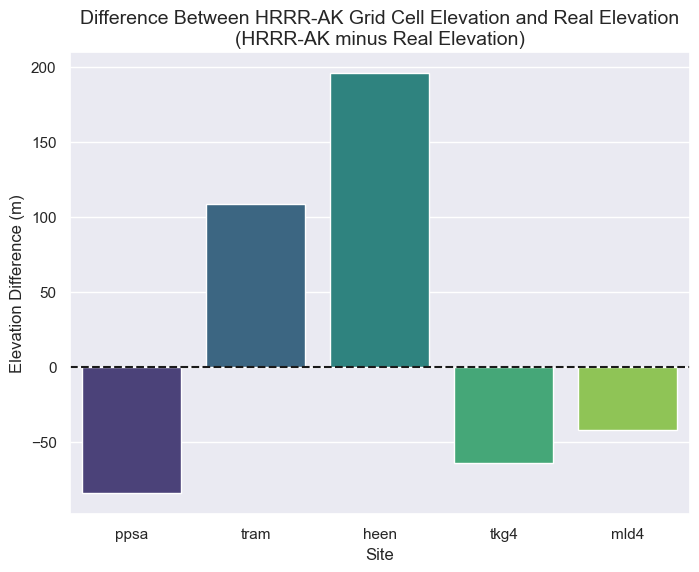

In [48]:
# make a box plot to visualize the elevation differences
plt.figure(figsize=(8, 6))
sns.barplot(x='site', y='diff', data=df_elevation, palette='viridis')
plt.axhline(0, color='k', linestyle='--')
plt.title('Difference Between HRRR-AK Grid Cell Elevation and Real Elevation\n(HRRR-AK minus Real Elevation)', fontsize=14)
plt.ylabel('Elevation Difference (m)', fontsize=12)
plt.xlabel('Site', fontsize=12)
plt.show()

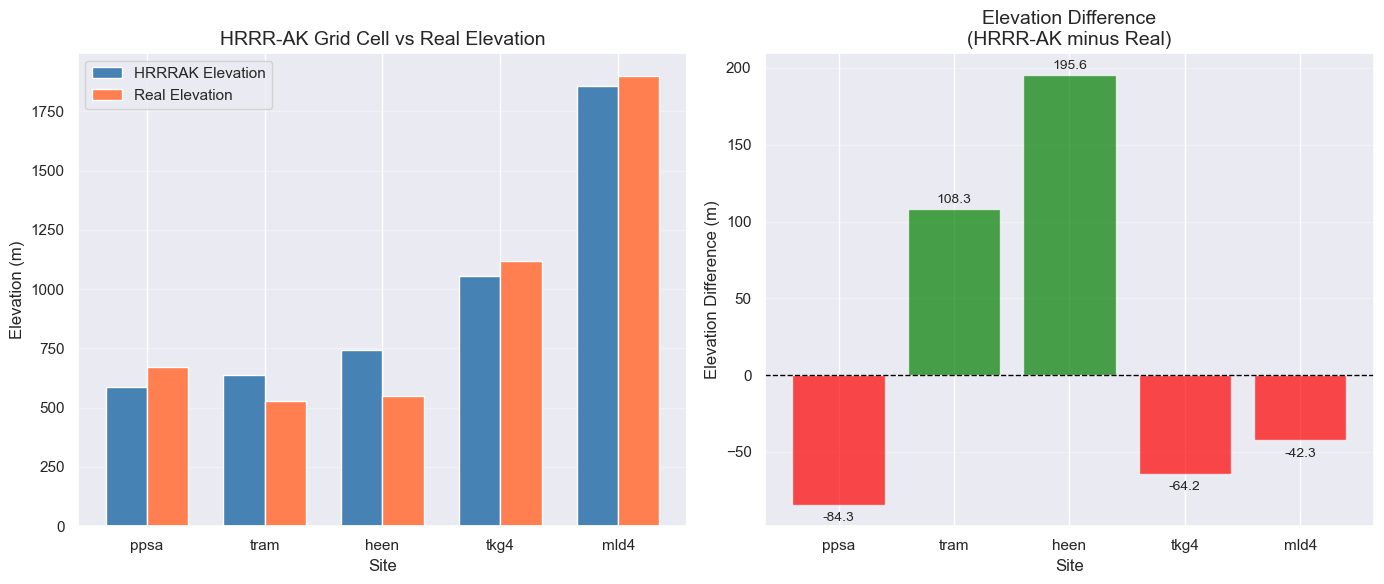

In [47]:
# make a similar plot except with all three bars for each site (hrrrak elevation, real elevation, and difference)
# Using subplots to handle the different scales properly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: HRRRAK vs Real elevation
x = np.arange(len(df_elevation['site']))
width = 0.35

bars1 = ax1.bar(x - width/2, df_elevation['hrrrak_elevation_m'], width, label='HRRRAK Elevation', color='steelblue')
bars2 = ax1.bar(x + width/2, df_elevation['real_elevation_m'], width, label='Real Elevation', color='coral')

ax1.set_xlabel('Site', fontsize=12)
ax1.set_ylabel('Elevation (m)', fontsize=12)
ax1.set_title('HRRR-AK Grid Cell vs Real Elevation', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(df_elevation['site'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right plot: Difference elevation
colors = ['green' if x >= 0 else 'red' for x in df_elevation['diff']]
ax2.bar(df_elevation['site'], df_elevation['diff'], color=colors, alpha=0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Site', fontsize=12)
ax2.set_ylabel('Elevation Difference (m)', fontsize=12)
ax2.set_title('Elevation Difference\n(HRRR-AK minus Real)', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on the diff bars
for i, v in enumerate(df_elevation['diff']):
    ax2.text(i, v + (2 if v >= 0 else -5), f'{v:.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()